# Chinese Handwriting Classification


### Step 1: Import relevant packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
import seaborn as sns

### Step 2: Load and explore the dataset

In [2]:
data = pd.read_csv('Chinese_MINST_Dataset/chinese_mnist.csv')
print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())
print("\nDataset info:")
print(data.info())
print("\nUnique values:")
print(f"Number of unique values: {data['value'].nunique()}")
print(f"Number of unique characters: {data['character'].nunique()}")

Dataset shape: (15000, 5)

First few rows:
   suite_id  sample_id  code  value character
0         1          1    10      9         九
1         1         10    10      9         九
2         1          2    10      9         九
3         1          3    10      9         九
4         1          4    10      9         九

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   suite_id   15000 non-null  int64 
 1   sample_id  15000 non-null  int64 
 2   code       15000 non-null  int64 
 3   value      15000 non-null  int64 
 4   character  15000 non-null  object
dtypes: int64(4), object(1)
memory usage: 586.1+ KB
None

Unique values:
Number of unique values: 15
Number of unique characters: 15


In [3]:
def load_images_flat(data):
    images = []  # 64x64 float images
    flats = []   # 4096-d float vectors
    labels = []
    for _, row in data.iterrows():
        img_path = f"Chinese_MINST_Dataset/data/data/input_{row['suite_id']}_{row['sample_id']}_{row['code']}.jpg"
        if os.path.exists(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            img = img / 255.0
            images.append(img)
            flats.append(img.reshape(-1))
            labels.append(row['value'])
    return np.array(images), np.array(flats), np.array(labels)

X_img, X_flat, y_raw = load_images_flat(data)
print(f"Images: {X_img.shape}, Flat: {X_flat.shape}, Labels: {y_raw.shape}")

unique_labels = np.sort(np.unique(y_raw))
label_to_index = {lab: i for i, lab in enumerate(unique_labels)}
y = np.array([label_to_index[v] for v in y_raw])

Images: (15000, 64, 64), Flat: (15000, 4096), Labels: (15000,)


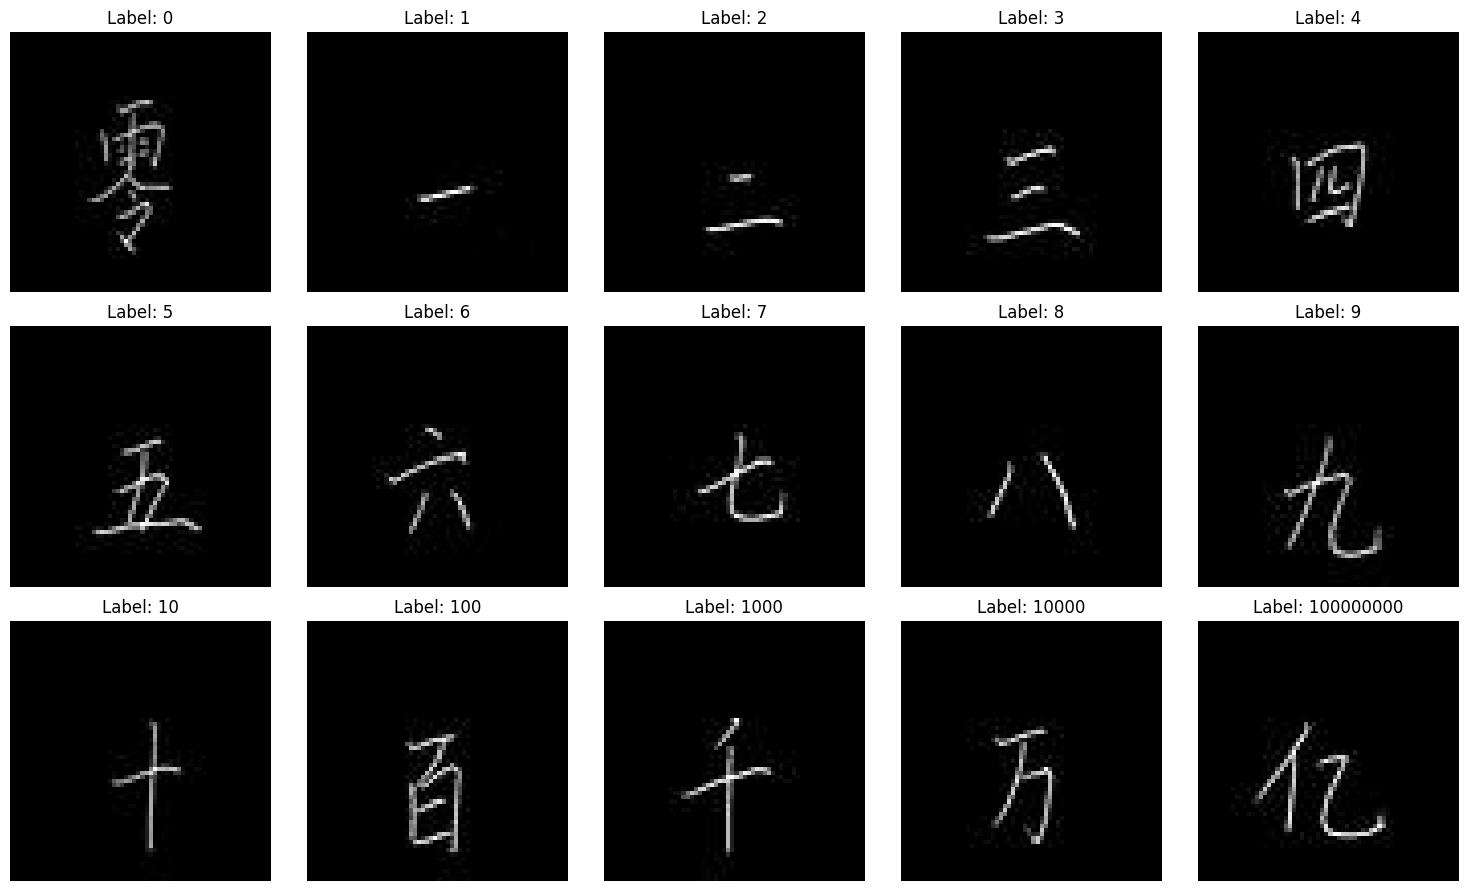

In [4]:
import math

# Ensure images and raw labels are available
if 'X_img' not in globals() or 'y_raw' not in globals():
    X_img, X_flat, y_raw = load_images_flat(data)

classes = np.sort(np.unique(y_raw))
fig_cols = 5
fig_rows = math.ceil(len(classes) / fig_cols)
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(3*fig_cols, 3*fig_rows))
axes = axes.flatten()
for i, cls in enumerate(classes):
    idx = np.where(y_raw == cls)[0][0]
    axes[i].imshow(X_img[idx], cmap='gray')
    axes[i].set_title(f"Label: {cls}")
    axes[i].axis('off')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [5]:
from collections import defaultdict


def stratified_sample_indices(y, per_class_train, per_class_test, random_state=42):
    rng = np.random.default_rng(random_state)
    class_to_idx = defaultdict(list)
    for idx, c in enumerate(y):
        class_to_idx[c].append(idx)

    train_idx, test_idx = [], []
    for c, idxs in class_to_idx.items():
        idxs = np.array(idxs)
        rng.shuffle(idxs)
        t_count = per_class_train
        v_count = per_class_test
        if len(idxs) < t_count + v_count:
            raise ValueError(f"Not enough samples in class {c}: have {len(idxs)}, need {t_count+v_count}")
        train_idx.extend(idxs[:t_count])
        test_idx.extend(idxs[t_count:t_count + v_count])
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return np.array(train_idx), np.array(test_idx)


def make_split(X_flat, y, total_train, total_test, random_state=42):
    n_classes = len(np.unique(y))
    per_class_train = total_train // n_classes
    per_class_test = total_test // n_classes
    tr_idx, te_idx = stratified_sample_indices(y, per_class_train, per_class_test, random_state)
    return X_flat[tr_idx], X_flat[te_idx], y[tr_idx], y[te_idx]


# Create the two required splits
Xtr5k, Xte1k, ytr5k, yte1k = make_split(X_flat, y, total_train=5000, total_test=1000, random_state=42)
Xtr10k, Xte1k_bis, ytr10k, yte1k_bis = make_split(X_flat, y, total_train=10000, total_test=1000, random_state=42)
# Keep the same 1k test for both comparisons
Xte1k, yte1k = Xte1k, yte1k

### Step 3: Stratified sampling to create 5,000-train/1,000-test and 10,000-train/1,000-test splits

In [6]:
print("Train 5k class counts:", np.bincount(ytr5k))
print("Train 10k class counts:", np.bincount(ytr10k))
print("Test 1k class counts:", np.bincount(yte1k))

Train 5k class counts: [333 333 333 333 333 333 333 333 333 333 333 333 333 333 333]
Train 10k class counts: [666 666 666 666 666 666 666 666 666 666 666 666 666 666 666]
Test 1k class counts: [66 66 66 66 66 66 66 66 66 66 66 66 66 66 66]


### Step 5–7: Initialize classifiers (KNN k=3, DT defaults, SGD max_iter=250), fit on train splits, and predict on test

### Step 8: Report accuracy, precision, recall, F1, and confusion matrices for each classifier and training size


=== Results (5k train, 1k test) ===

KNN Accuracy: 0.3586
              precision    recall  f1-score   support

           0     0.8654    0.6818    0.7627        66
           1     0.1480    0.9394    0.2557        66
           2     0.2602    0.4848    0.3386        66
           3     0.2979    0.2121    0.2478        66
           4     0.5000    0.2273    0.3125        66
           5     0.3750    0.0909    0.1463        66
           6     0.3191    0.2273    0.2655        66
           7     0.4444    0.1818    0.2581        66
           8     0.9811    0.7879    0.8739        66
           9     0.6667    0.1818    0.2857        66
          10     0.4938    0.6061    0.5442        66
          11     0.7692    0.1515    0.2532        66
          12     0.6818    0.2273    0.3409        66
          13     0.4848    0.2424    0.3232        66
          14     1.0000    0.1364    0.2400        66

    accuracy                         0.3586       990
   macro avg     0.55

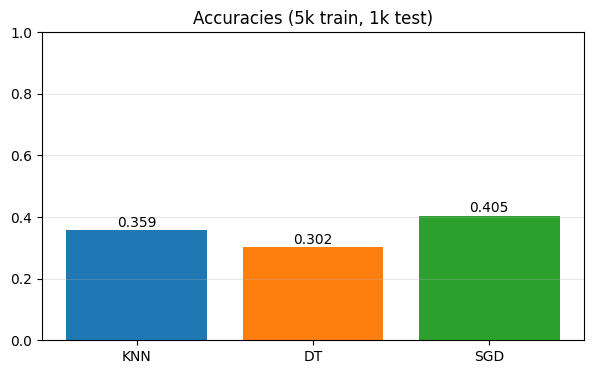

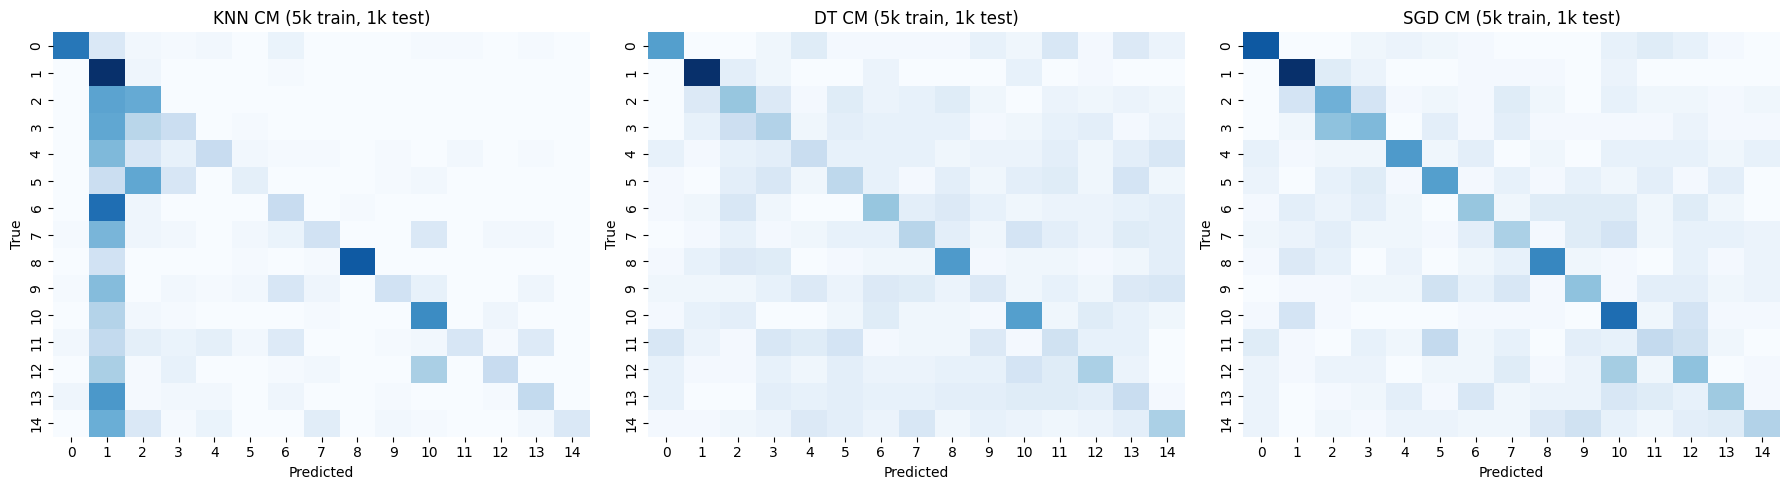


=== Results (10k train, 1k test) ===

KNN Accuracy: 0.6303
              precision    recall  f1-score   support

           0     0.9688    0.9394    0.9538        66
           1     0.2598    1.0000    0.4125        66
           2     0.3925    0.6364    0.4855        66
           3     0.5714    0.5455    0.5581        66
           4     0.8864    0.5909    0.7091        66
           5     0.7714    0.4091    0.5347        66
           6     0.6226    0.5000    0.5546        66
           7     0.8718    0.5152    0.6476        66
           8     0.9275    0.9697    0.9481        66
           9     0.8537    0.5303    0.6542        66
          10     0.6782    0.8939    0.7712        66
          11     0.9643    0.4091    0.5745        66
          12     0.9000    0.5455    0.6792        66
          13     0.9500    0.5758    0.7170        66
          14     1.0000    0.3939    0.5652        66

    accuracy                         0.6303       990
   macro avg     0.7

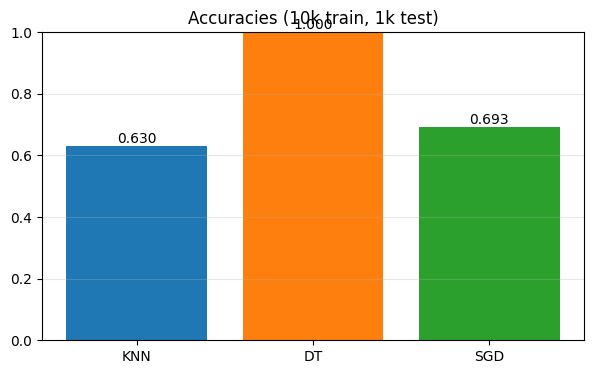

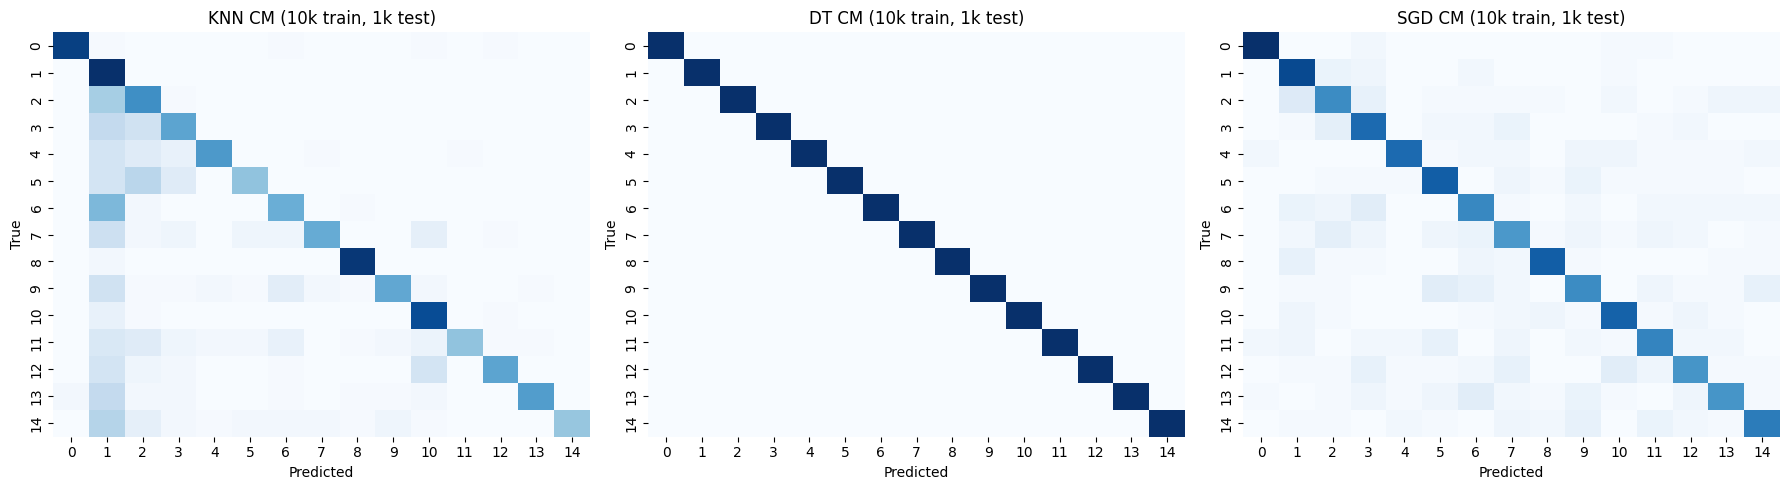

In [7]:
def train_and_evaluate(Xtr, ytr, Xte, yte, title_suffix=""):
    results = {}

    # KNN with k=3 
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(Xtr, ytr)
    ypred_knn = knn.predict(Xte)
    results['KNN'] = {
        'acc': accuracy_score(yte, ypred_knn),
        'report': classification_report(yte, ypred_knn, digits=4, output_dict=False),
        'cm': confusion_matrix(yte, ypred_knn)
    }

    # Decision Tree 
    dt = DecisionTreeClassifier()
    dt.fit(Xtr, ytr)
    ypred_dt = dt.predict(Xte)
    results['DT'] = {
        'acc': accuracy_score(yte, ypred_dt),
        'report': classification_report(yte, ypred_dt, digits=4, output_dict=False),
        'cm': confusion_matrix(yte, ypred_dt)
    }

    # SGD with max_iter=250 
    sgd = SGDClassifier(max_iter=250)
    sgd.fit(Xtr, ytr)
    ypred_sgd = sgd.predict(Xte)
    results['SGD'] = {
        'acc': accuracy_score(yte, ypred_sgd),
        'report': classification_report(yte, ypred_sgd, digits=4, output_dict=False),
        'cm': confusion_matrix(yte, ypred_sgd)
    }

    # Print summary metrics
    print(f"\n=== Results {title_suffix} ===")
    for name in ['KNN', 'DT', 'SGD']:
        print(f"\n{name} Accuracy: {results[name]['acc']:.4f}")
        print(results[name]['report'])

    # Plot accuracies for quick comparison
    labels = list(results.keys())
    values = [results[k]['acc'] for k in labels]
    plt.figure(figsize=(7,4))
    plt.bar(labels, values, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
    plt.ylim(0,1)
    plt.title(f"Accuracies {title_suffix}")
    for i, v in enumerate(values):
        plt.text(i, v+0.01, f"{v:.3f}", ha='center')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # Confusion matrices for each classifier
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    for ax, (name, res) in zip(axes, results.items()):
        sns.heatmap(res['cm'], ax=ax, cmap='Blues', annot=False, cbar=False)
        ax.set_title(f"{name} CM {title_suffix}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

    return results

results_5k = train_and_evaluate(Xtr5k, ytr5k, Xte1k, yte1k, title_suffix="(5k train, 1k test)")
results_10k = train_and_evaluate(Xtr10k, ytr10k, Xte1k, yte1k, title_suffix="(10k train, 1k test)")